# Experiment 3: Qwen3.5-9B on Llama-watermarked text
This cross-model control trains Qwen on the corpus watermarked by Llama and uses the Llama detector.
Run from `src/eval/`. Results, adapters, and figures use dedicated `qwen-on-llama` / `qwen_on_llama` paths.
The notebook expects open-keyspace results where plotted and the auxiliary BM25, cosine, BERTScore, bigram-overlap, and LCS files.


# Qwen3.5-9B experiment arm
Generated from the corresponding Llama notebook; all outputs are cleared.
Run from `src/eval/`. Results and figures use Qwen-only directories.
Six corpus sizes: 100, 500, 1000, 5000, 10000, 50000; 100 training epochs.
This arm uses Waterfall 0.3.4 and a different tokenizer. Token-based metrics
and LoRA layer coverage are not numerically identical to the Llama arm.


# Experiment 3 Evaluation (Question Prompts)

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

RESULTS_ROOT = Path("../../results/qwen_on_llama/experiment3")

BATCH_SIZE   = 32
FINAL_EPOCH  = 100
SAMPLE_SIZES = [100, 500, 1000, 5000, 10000, 50000]

PROMPT_TYPES  = ["train_questions", "held_out_questions"]
PROMPT_LABELS = {
    "train_questions":    "train",
    "held_out_questions": "held-out",
}
# One fixed color per question set, reused across every figure
PERTURB_COLORS = {
    "train_questions":    "#377eb8",  # blue
    "held_out_questions": "#e41a1c",  # red
}

# Font size for legends, axis labels and tick labels across every plot below.
FONT_SIZE = 14

# Where the figure PDFs are written.
FIG_DIR = Path("figures/qwen_on_llama/experiment3")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def _load_json(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def best_epoch(variant, n_samples, batch_size):
    """Epoch with highest Acc@1 for this question set."""
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
    if not base.is_dir():
        return None
    best_acc, best_ep = -1.0, None
    for ep_dir in sorted(base.iterdir()):
        if not ep_dir.is_dir():
            continue
        try:
            ep = int(ep_dir.name)
        except ValueError:
            continue
        d = _load_json(ep_dir / "verification_closed.json")
        if d is None:
            continue
        ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
        if ranks.size == 0:
            continue
        acc1 = float((ranks <= 1).mean())
        if acc1 > best_acc:
            best_acc, best_ep = acc1, ep
    return best_ep


def metrics_from_ranks(ranks):
    return {"acc@1": float((ranks <= 1).mean())}


def load_acc1_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / "verification_closed.json")
    d = _load_json(path)
    if d is None:
        return None
    ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
    if ranks.size == 0:
        return None
    return metrics_from_ranks(ranks)


def load_bm25_acc1_for_epoch(variant, n_samples, batch_size, epoch,
                             source, corpus_type="original"):
    """Acc@1 from `bm25_{source}_{corpus_type}.json`. `source` is answer/prompt."""
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / f"bm25_{source}_{corpus_type}.json")
    d = _load_json(path)
    if d is None:
        return None
    ranks = np.asarray(d["correct_ranks"], dtype=np.int64)
    if ranks.size == 0:
        return None
    return metrics_from_ranks(ranks)


def load_correctq_margin_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    path = (RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
            / str(epoch) / "verification_closed.json")
    d = _load_json(path)
    if d is None:
        return None
    correct_scores = np.asarray(d["correct_scores"], dtype=np.float64)
    top_scores     = np.asarray(d["top_scores"],     dtype=np.float64)
    if correct_scores.size == 0 or top_scores.shape[0] == 0:
        return None
    margins = top_scores[:, 0] - top_scores[:, 1]
    return {"correct_q": float(correct_scores.mean()),
            "margin":    float(margins.mean())}


def load_genmetrics_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size) / str(epoch)
    cos = _load_json(base / "cosine_watermarked.json")
    bsc = _load_json(base / "bertscore_watermarked.json")
    big = _load_json(base / "bigrams.json")
    lcs = _load_json(base / "lcs_watermarked.json")
    out = {
        "semsim":    None if cos is None else cos.get("mean"),
        "bertscore": None if bsc is None else bsc.get("mean_f1"),
        "rouge2":    None if big is None else big.get("frac_unique"),
        "normlcs":   None if lcs is None else lcs.get("mean_norm_lcs"),
    }
    if all(v is None for v in out.values()):
        return None
    return out


def load_rank_len_for_epoch(variant, n_samples, batch_size, epoch):
    if epoch is None:
        return None
    base = RESULTS_ROOT / variant / str(n_samples) / str(batch_size) / str(epoch)
    d = _load_json(base / "verification_closed.json")
    normrank = None
    if d is not None:
        ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
        if ranks.size:
            normrank = float((ranks / d["n_candidates"]).mean())
    lcs = _load_json(base / "lcs_watermarked.json")
    normlen = None if lcs is None else lcs.get("mean_norm_len")
    if normrank is None and normlen is None:
        return None
    return {"normrank": normrank, "normlen": normlen}


def collect_per_level(loader, sample_sizes=SAMPLE_SIZES, batch_size=BATCH_SIZE,
                      **loader_kwargs):
    """-> {prompt_type: {n: metrics}} at each set's best checkpoint.
"""
    out = {}
    for pt in PROMPT_TYPES:
        by_n = {}
        for n in sample_sizes:
            be = best_epoch(pt, n, batch_size)
            m = loader(pt, n, batch_size, be, **loader_kwargs)
            if m is not None:
                m = dict(m, _epoch=be)
                by_n[n] = m
        out[pt] = by_n
    return out

In [3]:
def _level_color(pt):
    return PERTURB_COLORS[pt]


def _two_part_legend(ax, style_handles, loc_color="lower left",
                     loc_style="upper right", bbox_color=None, bbox_style=None,
                     handlelength=None):

    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc=loc_color, fontsize=FONT_SIZE,
                    title="questions", bbox_to_anchor=bbox_color,
                    handlelength=handlelength)
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc=loc_style, fontsize=FONT_SIZE,
              bbox_to_anchor=bbox_style, handlelength=handlelength)


def plot_paired_over_n(collected, key_a, key_b, label_a, label_b,
                       title, ylabel, save_path=None, ylim=(-0.02, 1.02),
                       loc_color="lower left", loc_style="upper right",
                       bbox_color=None, bbox_style=None, handlelength=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x].get(key_a, float("nan")) for x in xs],
                linestyle="-", marker="o", color=c, lw=2.0)
        ax.plot(xs, [by_n[x].get(key_b, float("nan")) for x in xs],
                linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label=label_a),
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label=label_b),
    ]
    _two_part_legend(ax, style_handles, loc_color, loc_style,
                     bbox_color, bbox_style, handlelength)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

## Acc@1 across question sets

     train  N=100:0.960@100 N=500:0.854@100 N=1000:0.784@95 N=5000:0.158@100 N=10000:0.024@100 N=50000:0.001@90
  held-out  N=100:0.040@45 N=500:0.008@60 N=1000:0.003@25 N=5000:0.001@10 N=10000:0.002@85 N=50000:0.001@35


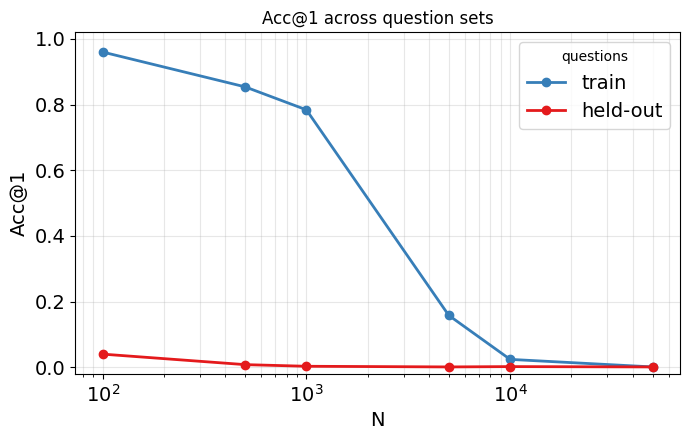

In [4]:
acc1_data = collect_per_level(load_acc1_for_epoch)

for pt in PROMPT_TYPES:
    row = " ".join(
        f"N={n}:{acc1_data[pt][n]['acc@1']:.3f}@{acc1_data[pt][n]['_epoch']}"
        for n in sorted(acc1_data[pt]))
    print(f"{PROMPT_LABELS[pt]:>10s}  {row}")


def plot_acc1(collected, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        ax.plot(xs, [by_n[x]["acc@1"] for x in xs],
                linestyle="-", marker="o", color=_level_color(pt), lw=2.0,
                label=PROMPT_LABELS[pt])
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("Acc@1 across question sets")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="questions")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1(acc1_data, save_path=FIG_DIR / "exp3_acc1_questions.pdf")

## BM25 baselines across question sets

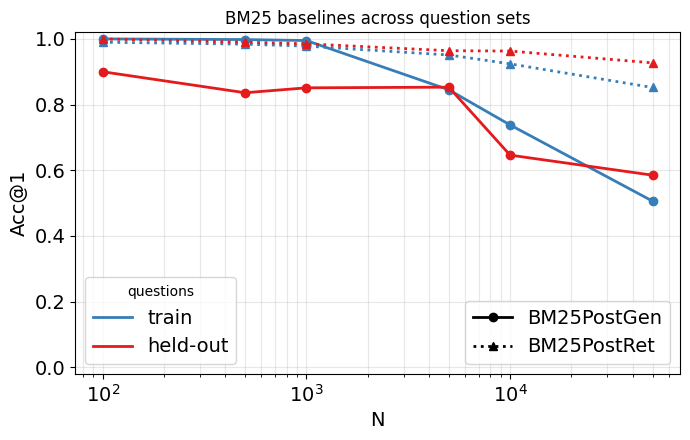

In [5]:
bm25_postgen = collect_per_level(load_bm25_acc1_for_epoch, source="answer")
bm25_postret = collect_per_level(load_bm25_acc1_for_epoch, source="prompt")


def plot_bm25(postgen, postret, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        c = _level_color(pt)
        bg = postgen.get(pt, {})
        xs = sorted(bg.keys())
        if xs:
            ax.plot(xs, [bg[x]["acc@1"] for x in xs],
                    linestyle="-", marker="o", color=c, lw=2.0)
        br = postret.get(pt, {})
        xs = sorted(br.keys())
        if xs:
            ax.plot(xs, [br[x]["acc@1"] for x in xs],
                    linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("BM25 baselines across question sets")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label="BM25PostGen"),
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label="BM25PostRet"),
    ]
    _two_part_legend(ax, style_handles, loc_style="lower right")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_bm25(bm25_postgen, bm25_postret, save_path=FIG_DIR / "exp3_bm25_baselines_questions.pdf")

## Acc@1 : WMCite vs. BM25 baselines across question sets

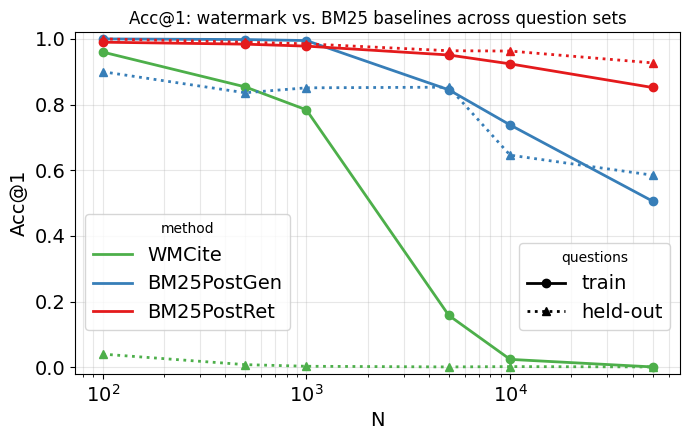

In [6]:
METHOD_COLORS = {
    "watermark":    "#4daf4a",  # green
    "bm25_postgen": "#377eb8",  # blue
    "bm25_postret": "#e41a1c",  # red
}
METHOD_LABELS = {
    "watermark":    "WMCite",
    "bm25_postgen": "BM25PostGen",
    "bm25_postret": "BM25PostRet",
}
SET_STYLES  = {"train_questions": "-",  "held_out_questions": ":"}
SET_MARKERS = {"train_questions": "o",  "held_out_questions": "^"}


def plot_acc1_combined(watermark, postgen, postret, save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    methods = [
        ("watermark",    watermark),
        ("bm25_postgen", postgen),
        ("bm25_postret", postret),
    ]
    for mkey, data in methods:
        for pt in PROMPT_TYPES:
            by_n = data.get(pt, {})
            xs = sorted(by_n.keys())
            if not xs:
                continue
            ax.plot(xs, [by_n[x]["acc@1"] for x in xs],
                    linestyle=SET_STYLES[pt], marker=SET_MARKERS[pt],
                    color=METHOD_COLORS[mkey], lw=2.0)
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title("Acc@1: watermark vs. BM25 baselines across question sets")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")

    # Two-part legend: color -> method, line style -> question set.
    color_handles = [Line2D([0], [0], color=METHOD_COLORS[m], lw=2.0,
                            label=METHOD_LABELS[m])
                     for m in ("watermark", "bm25_postgen", "bm25_postret")]
    style_handles = [Line2D([0], [0], color="black", lw=2.0,
                            linestyle=SET_STYLES[pt], marker=SET_MARKERS[pt],
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc="lower left",
                    bbox_to_anchor=(0.0, 0.1), fontsize=FONT_SIZE,
                    title="method")
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right",
              bbox_to_anchor=(1.0, 0.1), fontsize=FONT_SIZE,
              title="questions")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1_combined(acc1_data, bm25_postgen, bm25_postret,
                   save_path=FIG_DIR / "exp3_acc1_combined_questions.pdf")

## CorrectQ and Margin across question sets

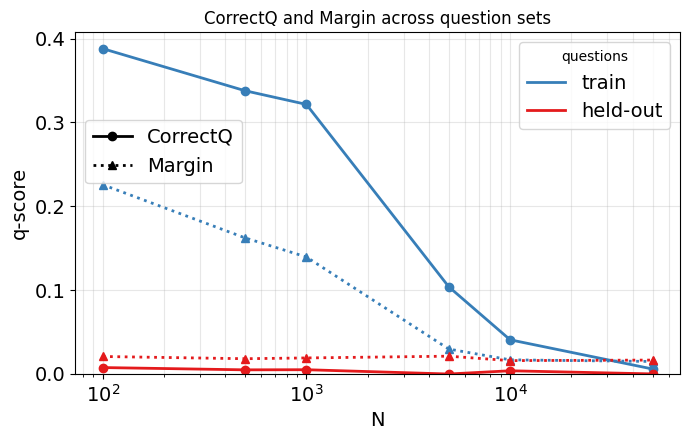

In [7]:
cqm = collect_per_level(load_correctq_margin_for_epoch)

plot_paired_over_n(
    cqm, "correct_q", "margin", "CorrectQ", "Margin",
    title="CorrectQ and Margin across question sets",
    ylabel="q-score", ylim=(0.0, None),
    save_path=FIG_DIR / "exp3_correctq_margin_questions.pdf",
    loc_color="upper right", loc_style="center left",
    bbox_style=(0.0, 0.65),
)

## SemSim and BERTScore across question sets

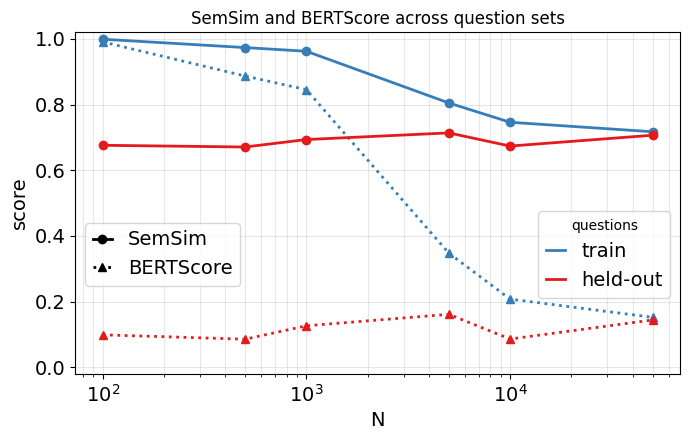

In [8]:
gen = collect_per_level(load_genmetrics_for_epoch)

plot_paired_over_n(
    gen, "semsim", "bertscore", "SemSim", "BERTScore",
    title="SemSim and BERTScore across question sets",
    ylabel="score",
    save_path=FIG_DIR / "exp3_semsim_bertscore_questions.pdf",
    loc_color="center right", loc_style="center left",
    bbox_color=(1.0, 0.35), bbox_style=(0.0, 0.35),
    handlelength=1.0,
)

## Rouge2 and NormLCS across question sets

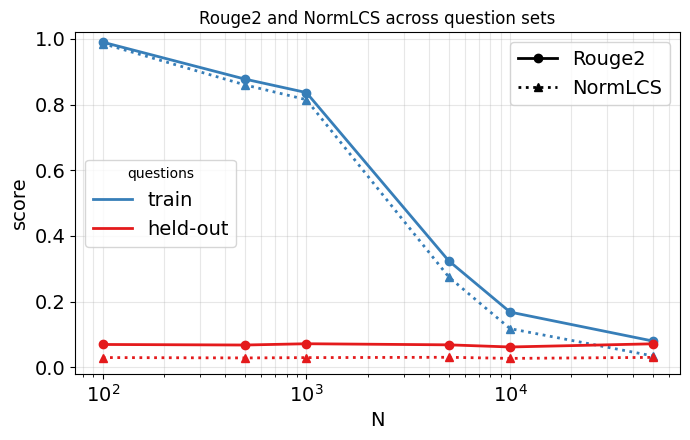

In [9]:
plot_paired_over_n(
    gen, "rouge2", "normlcs", "Rouge2", "NormLCS",
    title="Rouge2 and NormLCS across question sets",
    ylabel="score",
    save_path=FIG_DIR / "exp3_rouge2_normlcs_questions.pdf",
    loc_color="center left",
)

## NormRank and NormLen across question sets

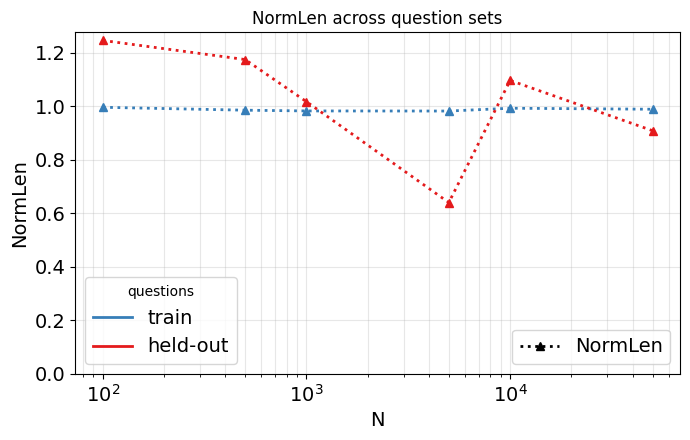

In [10]:
rl = collect_per_level(load_rank_len_for_epoch)


def plot_rank_len(collected, save_path=None):
    """NormLen over corpus size N (log-x)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x]["normlen"] for x in xs],
                linestyle=":", marker="^", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_title("NormLen across question sets")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("NormLen", fontsize=FONT_SIZE)
    ax.set_ylim(bottom=0.0)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle=":", marker="^",
               label="NormLen"),
    ]
    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc="lower left",
                    fontsize=FONT_SIZE, title="questions")
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_rank_len(rl, save_path=FIG_DIR / "exp3_normrank_normlen_questions.pdf")

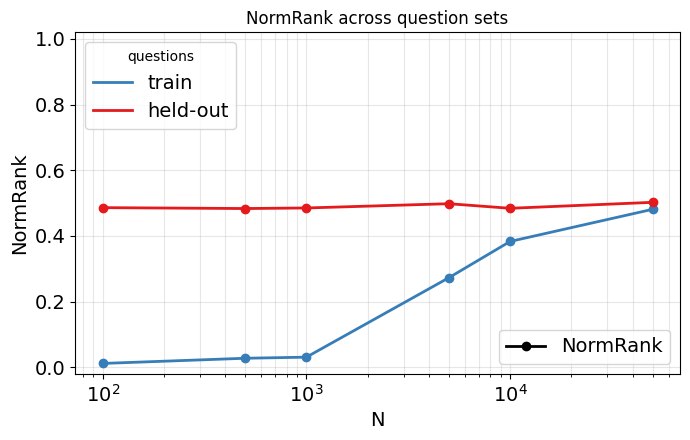

In [11]:
def plot_rank(collected, save_path=None):
    """NormRank over corpus size N (log-x)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        by_n = collected.get(pt, {})
        xs = sorted(by_n.keys())
        if not xs:
            continue
        c = _level_color(pt)
        ax.plot(xs, [by_n[x]["normrank"] for x in xs],
                linestyle="-", marker="o", color=c, lw=2.0)
    ax.set_xscale("log")
    ax.set_title("NormRank across question sets")
    ax.set_xlabel("N", fontsize=FONT_SIZE)
    ax.set_ylabel("NormRank", fontsize=FONT_SIZE)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    style_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle="-", marker="o",
               label="NormRank"),
    ]
    color_handles = [Line2D([0], [0], color=PERTURB_COLORS[pt], lw=2.0,
                            label=PROMPT_LABELS[pt]) for pt in PROMPT_TYPES]
    leg = ax.legend(handles=color_handles, loc="upper left",
                    fontsize=FONT_SIZE, title="questions")
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower right", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_rank(rl, save_path=FIG_DIR / "exp3_normrank_questions.pdf")

## Loss trajectories during training

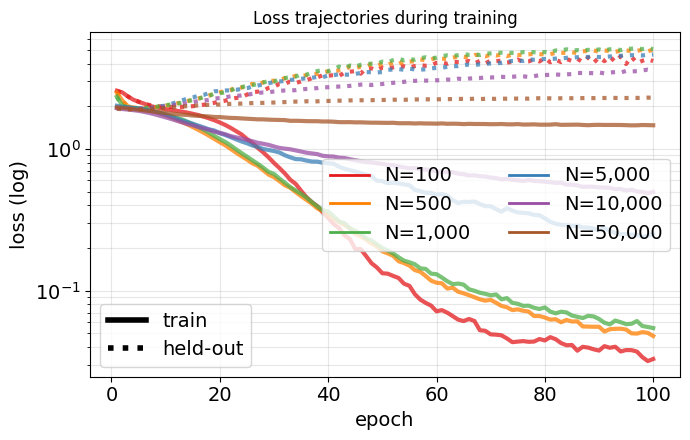

In [12]:
TRAINING_METADATA_ROOT = Path("../../training_metadata/qwen_on_llama/questions")

SIZE_COLORS = {
    100:   "#e41a1c",  # red
    500:   "#ff7f00",  # orange
    1000:  "#4daf4a",  # green
    5000:  "#377eb8",  # blue
    10000: "#984ea3",  # purple
    50000: "#a65628",  # brown
}


def load_loss_trajectory(n_samples, batch_size, final_epoch=FINAL_EPOCH):
    state = _load_json(TRAINING_METADATA_ROOT / str(n_samples) / str(batch_size)
                       / "loss_history.json")
    if state is None:
        return None
    log = state["log_history"]
    te = np.array([e["epoch"]           for e in log if "eval_train_loss" in e])
    tl = np.array([e["eval_train_loss"] for e in log if "eval_train_loss" in e])
    he = np.array([e["epoch"]             for e in log if "eval_heldout_loss" in e])
    hl = np.array([e["eval_heldout_loss"] for e in log if "eval_heldout_loss" in e])
    if hl.size == 0:
        he = np.array([e["epoch"]     for e in log if "eval_loss" in e])
        hl = np.array([e["eval_loss"] for e in log if "eval_loss" in e])
    return {"train_epoch": te, "train_loss": tl, "held_epoch": he, "held_loss": hl}


def plot_loss_trajectory(save_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for n in SAMPLE_SIZES:
        ld = load_loss_trajectory(n, BATCH_SIZE)
        if ld is None:
            continue
        c = SIZE_COLORS[n]
        if ld["train_loss"].size:
            ax.plot(ld["train_epoch"], ld["train_loss"], color=c,
                    linestyle="-", lw=3, alpha=0.75)
        if ld["held_loss"].size:
            ax.plot(ld["held_epoch"], ld["held_loss"], color=c,
                    linestyle=":", lw=3, alpha=0.75)
    ax.set_yscale("log")
    ax.set_title("Loss trajectories during training")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("loss (log)", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")

    color_handles = [Line2D([0], [0], color=SIZE_COLORS[n], lw=2.0,
                            label=f"N={n:,}") for n in SAMPLE_SIZES]
    style_handles = [
        Line2D([0], [0], color="black", lw=4.0, linestyle="-", label="train"),
        Line2D([0], [0], color="black", lw=4.0, linestyle=":", label="held-out"),
    ]
    leg = ax.legend(handles=color_handles, loc="center right", ncol=2,
                    fontsize=FONT_SIZE)
    ax.add_artist(leg)
    ax.legend(handles=style_handles, loc="lower left", fontsize=FONT_SIZE)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_loss_trajectory(save_path=FIG_DIR / "exp3_loss_trajectory_questions.pdf")

## Acc@1 over training at N=100 across question sets

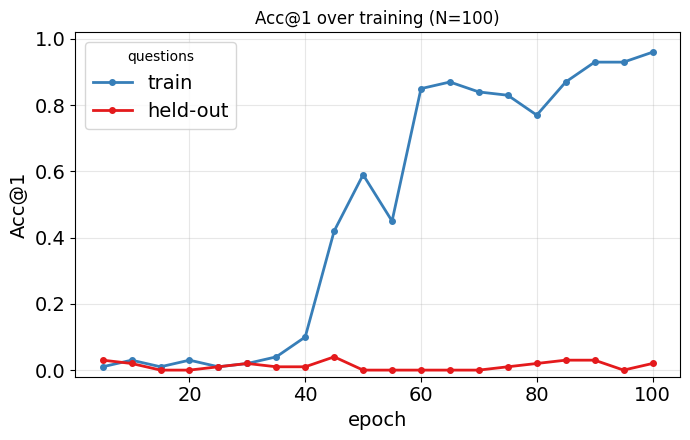

In [13]:
TRAJ_EPOCHS = list(range(5, 101, 5))
TRAJ_N      = 100


def collect_level_trajectory(variant, n_samples, batch_size, epochs=TRAJ_EPOCHS):
    eps, acc1, normrank = [], [], []
    for ep in epochs:
        d = _load_json(RESULTS_ROOT / variant / str(n_samples) / str(batch_size)
                       / str(ep) / "verification_closed.json")
        if d is None:
            continue
        ranks = np.asarray(d["correct_ranks"], dtype=np.float64)
        if ranks.size == 0:
            continue
        eps.append(ep)
        acc1.append(float((ranks <= 1).mean()))
        normrank.append(float((ranks / d["n_candidates"]).mean()))
    return {
        "epoch":    np.asarray(eps, dtype=np.int64),
        "acc1":     np.asarray(acc1, dtype=np.float64),
        "normrank": np.asarray(normrank, dtype=np.float64),
    }


def plot_acc1_trajectory_n100(save_path=None, n_samples=TRAJ_N):
    """Acc@1 vs. epoch at a fixed corpus size."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        t = collect_level_trajectory(pt, n_samples, BATCH_SIZE)
        if t["epoch"].size == 0:
            continue
        ax.plot(t["epoch"], t["acc1"], color=_level_color(pt), marker="o",
                ms=4, lw=2.0, label=PROMPT_LABELS[pt])
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"Acc@1 over training (N={n_samples})")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("Acc@1", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper left", fontsize=FONT_SIZE, title="questions")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_acc1_trajectory_n100(
    save_path=FIG_DIR / "exp3_acc1_trajectory_n100_questions.pdf")

## NormRank over training at N=100 across question sets

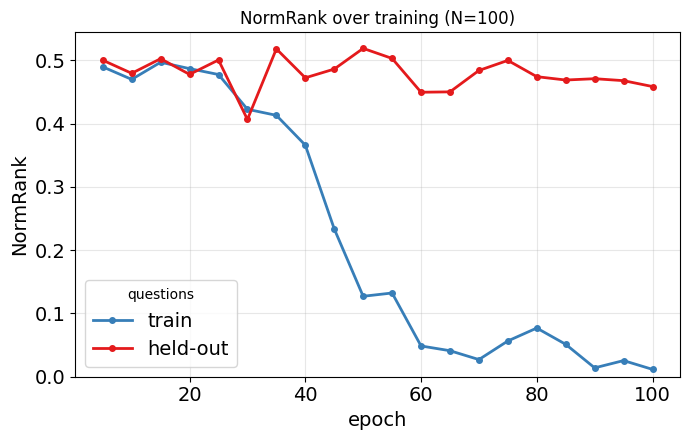

In [14]:
def plot_normrank_trajectory_n100(save_path=None, n_samples=TRAJ_N):
    """NormRank vs. epoch at a fixed corpus size."""
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    for pt in PROMPT_TYPES:
        t = collect_level_trajectory(pt, n_samples, BATCH_SIZE)
        if t["epoch"].size == 0:
            continue
        ax.plot(t["epoch"], t["normrank"], color=_level_color(pt), marker="o",
                ms=4, lw=2.0, label=PROMPT_LABELS[pt])
    ax.set_ylim(bottom=0.0)
    ax.set_title(f"NormRank over training (N={n_samples})")
    ax.set_xlabel("epoch", fontsize=FONT_SIZE)
    ax.set_ylabel("NormRank", fontsize=FONT_SIZE)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=FONT_SIZE, title="questions")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


plot_normrank_trajectory_n100(
    save_path=FIG_DIR / "exp3_normrank_trajectory_n100_questions.pdf")

## Paper-ready numeric tables

The primary table contains the exact values underlying the main attribution plot. The supplementary table contains retrieval, semantic, lexical, score, rank, and length metrics. The selected checkpoint and evaluation count are included for provenance. Missing metric files are reported as `NA`; rerunning this notebook after those evaluations finish fills them automatically. Raw-precision CSV files and LaTeX tables are produced for paper writing.

In [15]:
import pandas as pd
from IPython.display import display

MODEL_LABEL = 'Qwen on Llama watermark'
MODEL_SLUG = 'qwen_on_llama'
EXPERIMENT_NUMBER = 3
TABLE_DIR = Path("tables") / MODEL_SLUG
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _paper_level_value(source, prompt_type, n, key):
    row = source.get(prompt_type, {}).get(n) if isinstance(source, dict) else None
    return np.nan if row is None or row.get(key) is None else row[key]


def _paper_level_eval_count(prompt_type, n, epoch):
    if epoch is None:
        return np.nan
    result = _load_json(
        RESULTS_ROOT / prompt_type / str(n) / str(BATCH_SIZE)
        / str(epoch) / "verification_closed.json"
    )
    return np.nan if result is None else len(result.get("correct_ranks", []))


paper_rows = []
for prompt_type in PROMPT_TYPES:
    for n in SAMPLE_SIZES:
        main = acc1_data.get(prompt_type, {}).get(n, {})
        epoch = main.get("_epoch")
        paper_rows.append({
            "model": MODEL_LABEL,
            "condition": PROMPT_LABELS[prompt_type],
            "prompt_type": prompt_type,
            "corpus_size": n,
            "selected_epoch": epoch,
            "n_evaluated": _paper_level_eval_count(prompt_type, n, epoch),
            "acc_at_1": main.get("acc@1", np.nan),
            "bm25_postgen_acc_at_1": _paper_level_value(
                bm25_postgen, prompt_type, n, "acc@1"
            ),
            "bm25_postret_acc_at_1": _paper_level_value(
                bm25_postret, prompt_type, n, "acc@1"
            ),
            "correct_q": _paper_level_value(cqm, prompt_type, n, "correct_q"),
            "margin": _paper_level_value(cqm, prompt_type, n, "margin"),
            "semantic_similarity": _paper_level_value(gen, prompt_type, n, "semsim"),
            "bertscore_f1": _paper_level_value(gen, prompt_type, n, "bertscore"),
            "rouge2_bigram_overlap": _paper_level_value(gen, prompt_type, n, "rouge2"),
            "normalized_lcs": _paper_level_value(gen, prompt_type, n, "normlcs"),
            "normalized_rank": _paper_level_value(rl, prompt_type, n, "normrank"),
            "normalized_length": _paper_level_value(rl, prompt_type, n, "normlen"),
        })

paper_all_metrics = pd.DataFrame(paper_rows)
identifier_columns = [
    "model", "condition", "prompt_type", "corpus_size",
    "selected_epoch", "n_evaluated",
]
paper_primary = paper_all_metrics[identifier_columns + ["acc_at_1"]]
paper_supplementary = paper_all_metrics[
    identifier_columns + [
        "bm25_postgen_acc_at_1", "bm25_postret_acc_at_1", "correct_q", "margin",
        "semantic_similarity", "bertscore_f1", "rouge2_bigram_overlap",
        "normalized_lcs", "normalized_rank", "normalized_length",
    ]
]

display(paper_primary.round(4).fillna("NA"))
display(paper_supplementary.round(4).fillna("NA"))

stem = f"experiment{EXPERIMENT_NUMBER}"
paper_all_metrics.to_csv(TABLE_DIR / f"{stem}_all_metrics.csv", index=False)
paper_primary.to_csv(TABLE_DIR / f"{stem}_primary.csv", index=False)
paper_supplementary.to_csv(TABLE_DIR / f"{stem}_supplementary.csv", index=False)

print(paper_primary.to_latex(index=False, float_format=lambda x: f"{x:.4f}", na_rep="--"))
print(paper_supplementary.to_latex(index=False, float_format=lambda x: f"{x:.4f}", na_rep="--"))

,model,condition,prompt_type,corpus_size,selected_epoch,n_evaluated,acc_at_1
0,Qwen on Llama watermark,train,train_questions,100,100,100,0.960
1,Qwen on Llama watermark,train,train_questions,500,100,500,0.854
2,Qwen on Llama watermark,train,train_questions,1000,95,1000,0.784
3,Qwen on Llama watermark,train,train_questions,5000,100,1000,0.158
4,Qwen on Llama watermark,train,train_questions,10000,100,1000,0.024
5,Qwen on Llama watermark,train,train_questions,50000,90,1000,0.001
6,Qwen on Llama watermark,held-out,held_out_questions,100,45,100,0.040
7,Qwen on Llama watermark,held-out,held_out_questions,500,60,500,0.008
8,Qwen on Llama watermark,held-out,held_out_questions,1000,25,1000,0.003
9,Qwen on Llama watermark,held-out,held_out_questions,5000,10,1000,0.001


,model,condition,prompt_type,corpus_size,selected_epoch,n_evaluated,bm25_postgen_acc_at_1,bm25_postret_acc_at_1,correct_q,margin,semantic_similarity,bertscore_f1,rouge2_bigram_overlap,normalized_lcs,normalized_rank,normalized_length
0,Qwen on Llama watermark,train,train_questions,100,100,100,1.000,0.990,0.3881,0.2258,0.9991,0.9908,0.9902,0.9858,0.0116,0.9964
1,Qwen on Llama watermark,train,train_questions,500,100,500,0.998,0.984,0.3379,0.1623,0.9736,0.8869,0.8775,0.8599,0.0274,0.9855
2,Qwen on Llama watermark,train,train_questions,1000,95,1000,0.995,0.978,0.3216,0.1395,0.9624,0.8455,0.8366,0.8149,0.0307,0.9827
3,Qwen on Llama watermark,train,train_questions,5000,100,1000,0.845,0.951,0.1039,0.0296,0.8050,0.3476,0.3240,0.2750,0.2725,0.9823
4,Qwen on Llama watermark,train,train_questions,10000,100,1000,0.738,0.924,0.0406,0.0167,0.7461,0.2076,0.1680,0.1176,0.3831,0.9928
5,Qwen on Llama watermark,train,train_questions,50000,90,1000,0.506,0.852,0.0058,0.0148,0.7172,0.1521,0.0801,0.0347,0.4809,0.9891
6,Qwen on Llama watermark,held-out,held_out_questions,100,45,100,0.900,1.000,0.0075,0.0207,0.6760,0.0988,0.0694,0.0295,0.4861,1.2463
7,Qwen on Llama watermark,held-out,held_out_questions,500,60,500,0.836,0.990,0.0048,0.0180,0.6708,0.0854,0.0677,0.0284,0.4834,1.1748
8,Qwen on Llama watermark,held-out,held_out_questions,1000,25,1000,0.851,0.985,0.0049,0.0190,0.6935,0.1263,0.0716,0.0293,0.4851,1.0173
9,Qwen on Llama watermark,held-out,held_out_questions,5000,10,1000,0.853,0.964,-0.0002,0.0211,0.7137,0.1613,0.0683,0.0304,0.4981,0.6402


\begin{tabular}{lllrrrr}
\toprule
model & condition & prompt_type & corpus_size & selected_epoch & n_evaluated & acc_at_1 \\
\midrule
Qwen on Llama watermark & train & train_questions & 100 & 100 & 100 & 0.9600 \\
Qwen on Llama watermark & train & train_questions & 500 & 100 & 500 & 0.8540 \\
Qwen on Llama watermark & train & train_questions & 1000 & 95 & 1000 & 0.7840 \\
Qwen on Llama watermark & train & train_questions & 5000 & 100 & 1000 & 0.1580 \\
Qwen on Llama watermark & train & train_questions & 10000 & 100 & 1000 & 0.0240 \\
Qwen on Llama watermark & train & train_questions & 50000 & 90 & 1000 & 0.0010 \\
Qwen on Llama watermark & held-out & held_out_questions & 100 & 45 & 100 & 0.0400 \\
Qwen on Llama watermark & held-out & held_out_questions & 500 & 60 & 500 & 0.0080 \\
Qwen on Llama watermark & held-out & held_out_questions & 1000 & 25 & 1000 & 0.0030 \\
Qwen on Llama watermark & held-out & held_out_questions & 5000 & 10 & 1000 & 0.0010 \\
Qwen on Llama watermark & held-out